# Video Game Sales Analysis Project
## Project Overview

In this project, I analyze video game sales data to identify patterns that determine a game's success. Working as an analyst for the online store Ice, I use this information to help plan future advertising campaigns.

## Environment Setup and Required Libraries

In [ ]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

## Step 1: Loading and Initial Data Exploration

First, let's load our dataset and examine its basic properties:

In [ ]:
# Load the dataset
df = pd.read_csv('/datasets/games.csv')
df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [ ]:
# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [ ]:
df.describe(include='all')

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
count,16713,16715,16446.000000,16713,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000,10014,9949
unique,11559,31,NaN,12,NaN,NaN,NaN,NaN,NaN,96,8
top,Need for Speed: Most Wanted,PS2,NaN,Action,NaN,NaN,NaN,NaN,NaN,tbd,E
freq,12,2161,NaN,3369,NaN,NaN,NaN,NaN,NaN,2424,3990
mean,NaN,NaN,2006.484616,NaN,0.263377,0.145060,0.077617,0.047342,68.967679,NaN,NaN
std,NaN,NaN,5.877050,NaN,0.813604,0.503339,0.308853,0.186731,13.938165,NaN,NaN
min,NaN,NaN,1980.000000,NaN,0.000000,0.000000,0.000000,0.000000,13.000000,NaN,NaN
25%,NaN,NaN,2003.000000,NaN,0.000000,0.000000,0.000000,0.000000,60.000000,NaN,NaN
50%,NaN,NaN,2007.000000,NaN,0.080000,0.020000,0.000000,0.010000,71.000000,NaN,NaN
75%,NaN,NaN,2010.000000,NaN,0.240000,0.110000,0.040000,0.030000,79.000000,NaN,NaN


In [ ]:
# Check for duplicate entries
df.duplicated().sum()

0

In [ ]:
## Investigating the values in each column
for i in df.columns:
    print(i)
    print(df[i].unique())
    print('\n')

Name
['Wii Sports' 'Super Mario Bros.' 'Mario Kart Wii' ...
 'Woody Woodpecker in Crazy Castle 5' 'LMA Manager 2007'
 'Haitaka no Psychedelica']


Platform
['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' 'PS4' '3DS' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'WiiU' 'GC' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']


Year_of_Release
[2006. 1985. 2008. 2009. 1996. 1989. 1984. 2005. 1999. 2007. 2010. 2013.
 2004. 1990. 1988. 2002. 2001. 2011. 1998. 2015. 2012. 2014. 1992. 1997.
 1993. 1994. 1982. 2016. 2003. 1986. 2000.   nan 1995. 1991. 1981. 1987.
 1980. 1983.]


Genre
['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy' nan]


NA_sales
[4.136e+01 2.908e+01 1.568e+01 1.561e+01 1.127e+01 2.320e+01 1.128e+01
 1.396e+01 1.444e+01 2.693e+01 9.050e+00 9.710e+00 9.000e+00 8.920e+00
 1.500e+01 9.010e+00 7.020e+00 9.430e+00 1.278e+01 4.740e+00 6.380e+00
 1.083e+01 9.540e+00 9.660e+00 8.410e+00 

In [ ]:
## Explore the name column
name_labels = list(df['Name'].unique())
unique_names = [str(name) for name in name_labels]
unique_names.sort()
unique_names[0:10]

[' Beyblade Burst',
 ' Fire Emblem Fates',
 " Frozen: Olaf's Quest",
 ' Haikyu!! Cross Team Match!',
 ' Tales of Xillia 2',
 "'98 Koshien",
 '.hack//G.U. Vol.1//Rebirth',
 '.hack//G.U. Vol.2//Reminisce',
 '.hack//G.U. Vol.2//Reminisce (jp sales)',
 '.hack//G.U. Vol.3//Redemption']

### Key Questions to Answer:
- What's the total number of records in our dataset?
- What data types are present in each column?
- Are there any obvious issues with the data?
- Do we see any immediate patterns or anomalies?

-----

From the dataset, there are 16715 rows and 11 columns.

There are no obvious duplicate records.

The columns **Year_of_Release**, **NA_sales**, **EU_sales**, **JP_sales**, **Other_sales**, and **Critic_Score** have numeric data types. The columns **Name**, **Platform**, **Genre**, **User_Score**, and **Rating** have categorical or text data types.

Based on the nature of the data, **User_Score** would be better represented as a numeric data type, and **Year_of_Release** would be more appropriate as an integer, datetime, or ordered categorical variable.

The **Year_of_Release** column currently contains decimal values, but it should probably be stored as an integer since the decimal format looks unusual for a release year.

rom my observation, the **Name** column contains trailing spaces, so it will need to be corrected.

Only the columns **Platform**, **NA_sales**, **EU_sales**, **JP_sales**, and **Other_sales** contain all 16715 rows, so I will need to investigate the missing values in the other columns further.

-----

## Step 2: Data Preparation

### 2.1 Standardizing Column Names

In [ ]:
# Convert column names to lowercase
reg_cols_names = list(df.columns)
lowercase_cols = [col.lower() for col in reg_cols_names]
df = df.rename(columns = {old_col:new_col for old_col,new_col in zip(reg_cols_names,lowercase_cols)})

In [ ]:
# Verify the changes
df.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

### 2.2 Data Type Conversion

In [ ]:
# Check current data types
df.dtypes

name                object
platform            object
year_of_release    float64
genre               object
na_sales           float64
eu_sales           float64
jp_sales           float64
other_sales        float64
critic_score       float64
user_score          object
rating              object
dtype: object

In [ ]:
# Make changes to data types if necessary
# Describe the columns where the data types have been changed and why.

In [ ]:
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [ ]:
## change user_score to numeric data type
df['user_score'].unique() # show unique values in the user_score column

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

In [ ]:
## converted to numeric
df['user_score'] = pd.to_numeric(df['user_score'],errors='coerce')

## show unique values in the user_score column after converted
df['user_score'].unique()

array([8. , nan, 8.3, 8.5, 6.6, 8.4, 8.6, 7.7, 6.3, 7.4, 8.2, 9. , 7.9,
       8.1, 8.7, 7.1, 3.4, 5.3, 4.8, 3.2, 8.9, 6.4, 7.8, 7.5, 2.6, 7.2,
       9.2, 7. , 7.3, 4.3, 7.6, 5.7, 5. , 9.1, 6.5, 8.8, 6.9, 9.4, 6.8,
       6.1, 6.7, 5.4, 4. , 4.9, 4.5, 9.3, 6.2, 4.2, 6. , 3.7, 4.1, 5.8,
       5.6, 5.5, 4.4, 4.6, 5.9, 3.9, 3.1, 2.9, 5.2, 3.3, 4.7, 5.1, 3.5,
       2.5, 1.9, 3. , 2.7, 2.2, 2. , 9.5, 2.1, 3.6, 2.8, 1.8, 3.8, 0. ,
       1.6, 9.6, 2.4, 1.7, 1.1, 0.3, 1.5, 0.7, 1.2, 2.3, 0.5, 1.3, 0.2,
       0.6, 1.4, 0.9, 1. , 9.7])


-----

In the **user_score** column, I converted the data from a string type to a numeric type.
The column contained tbd(to be announce) values, null values, and numeric values stored as strings.
I decided to treat tbd as a null value because it is commonly used as a placeholder rather than a real score.

----


In [ ]:
## change Year_of_Release to integer data type
df['year_of_release'].unique() # show unique values in the year_of_release column

array([2006., 1985., 2008., 2009., 1996., 1989., 1984., 2005., 1999.,
       2007., 2010., 2013., 2004., 1990., 1988., 2002., 2001., 2011.,
       1998., 2015., 2012., 2014., 1992., 1997., 1993., 1994., 1982.,
       2016., 2003., 1986., 2000.,   nan, 1995., 1991., 1981., 1987.,
       1980., 1983.])

In [ ]:
## converted to integer
df['year_of_release'] = pd.to_numeric(df['year_of_release'],errors='coerce').astype('Int64')

## show unique values in the year_of_release column after converted
df['year_of_release'].unique()

<IntegerArray>
[2006, 1985, 2008, 2009, 1996, 1989, 1984, 2005, 1999, 2007, 2010, 2013, 2004,
 1990, 1988, 2002, 2001, 2011, 1998, 2015, 2012, 2014, 1992, 1997, 1993, 1994,
 1982, 2016, 2003, 1986, 2000, <NA>, 1995, 1991, 1981, 1987, 1980, 1983]
Length: 38, dtype: Int64

-----

In the **year_of_release** column, I converted the data from a decimal type to an integer type.
This makes the column look cleaner, and I kept the null values as null for now.

----


In [ ]:
## fix extra spaces in the name col
df['name'] = df['name'].str.strip()
name_labels = list(df['name'].unique())
unique_names = [str(name) for name in name_labels]
unique_names.sort()
unique_names[0:10]

["'98 Koshien",
 '.hack//G.U. Vol.1//Rebirth',
 '.hack//G.U. Vol.2//Reminisce',
 '.hack//G.U. Vol.2//Reminisce (jp sales)',
 '.hack//G.U. Vol.3//Redemption',
 '.hack//Infection Part 1',
 '.hack//Link',
 '.hack//Mutation Part 2',
 '.hack//Outbreak Part 3',
 '.hack//Quarantine Part 4: The Final Chapter']

In [ ]:
## Check for duplicate entries again
df.duplicated().sum()

0

-----

I stripped the extra spaces from the **name** column and checked whether doing so created any duplicate rows.

-----

In [ ]:
# Pay attention to the abbreviation TBD (to be determined). Specify how you intend to handle such cases.

### 2.3 Handling Missing Values

In [ ]:
# Examine missing values
df.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

-----


For missing values,

the **name** column has 2 missing values,

**year_of_release** has 269,

**genre** has 2,

**critic_score** has 8578,

**user_score** has 9125,

and **rating** has 6766.


-----

In [ ]:
# Calculate percentage of missing values
(df.isna().sum()/len(df) *100).round(2)

name                0.01
platform            0.00
year_of_release     1.61
genre               0.01
na_sales            0.00
eu_sales            0.00
jp_sales            0.00
other_sales         0.00
critic_score       51.32
user_score         54.59
rating             40.48
dtype: float64

-----

For the percentage of missing values in each column,

the **name** column has 0.01% missing,

**year_of_release** has 1.61%,

**genre** has 0.01%,

**critic_score** has 51.32%,

**user_score** has 54.59%,

and **rating** has 40.48%.

-----

In [ ]:
# Analyze patterns in missing values

In [ ]:
## name missing values 0.01%

name_na = df['name'].isna()
df[name_na]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


In [ ]:
## year_of_release missing values 1.61%

year_of_release_na = df['year_of_release'].isna()
df[year_of_release_na]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,<NA>,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,<NA>,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,Wii,<NA>,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,<NA>,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
609,Space Invaders,2600,<NA>,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16373,PDC World Championship Darts 2008,PSP,<NA>,Sports,0.01,0.00,0.00,0.00,43.0,NaN,E10+
16405,Freaky Flyers,GC,<NA>,Racing,0.01,0.00,0.00,0.00,69.0,6.5,T
16448,Inversion,PC,<NA>,Shooter,0.01,0.00,0.00,0.00,59.0,6.7,M
16458,Hakuouki: Shinsengumi Kitan,PS3,<NA>,Adventure,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [ ]:
## genre missing values 0.01%

genre_na = df['genre'].isna()
df[genre_na]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


In [ ]:
## critic_score missing values 51.32%

critic_score_na = df['critic_score'].isna()
df[critic_score_na]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [ ]:
## user_score missing values 54.59%

user_score_na = df['user_score'].isna()
df[user_score_na]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [ ]:
## rating missing values 40.48%

rating_na = df['rating'].isna()
df[rating_na]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [ ]:
# Handle missing values based on analysis
# Your code here to handle missing values according to your strategy

In [ ]:
## handling missing values for name column
df['name'] = df['name'].fillna("unknown name")

In [ ]:
## handling missing values for genre column
df['genre'] = df['genre'].fillna("unknown genre")

In [ ]:
# Why do you think the values are missing? Give possible reasons.
# Explain why you filled in the missing values as you did or why you decided to leave them blank.

-----



- Based on my analysis, I replaced the missing values in the **name** column with **unknown name** and the missing values in the **genre** column with **unknown genre**.
- There was no need to delete those rows, especially since both columns had only 0.01% missing values.
- Even though the **year_of_release**, **rating**, **critic_score**, and **user_score** columns had missing values, I decided to leave them as null.
- If I removed missing values from each of those columns, almost half of the dataset would be lost.
- In addition, those rows still contain useful information for statistical analysis.
- It is difficult to determine exactly why only two rows were missing values in the **name** and **genre** columns, but I noticed that one record had a release year of 1993 and a platform of **GEN**.
- In one case, Japanese sales were 0, and in the other, all sales columns had values except Japanese sales, which were also 0. This may suggest that the game was released outside Japan or had a non-Japanese edition.
- Around 1.6% of the data was missing values in the **year_of_release** column.
- One possible reason is that the information was not entered, and it is difficult to assign an exact year because some games were released across multiple platforms.
- It is also difficult to know exactly why some games are missing **rating**, **critic_score**, or **user_score** values, but possible reasons include the year of release, the popularity of the game, or a lack of enough reviews or could not determine the rating of the game.


-----

### 2.4 Calculate Total Sales

In [ ]:
# Calculate total sales across all regions and put them in a different column

## calculating total sales
df['global_sales'] = df.apply(lambda r: r['na_sales']+r['eu_sales']+r['jp_sales']+r['other_sales'],axis=1)
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


# Step 3: Analyzing Video Game Sales Data

## 3.1 Temporal Analysis of Game Releases
Let's first examine the distribution of game releases across different years to understand our data's coverage and significance:

In [ ]:
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


In [ ]:
# Create a DataFrame with game releases by year
df_games_per_year = df.groupby("year_of_release").agg(number_of_games = ("name","count")).reset_index(drop=False)

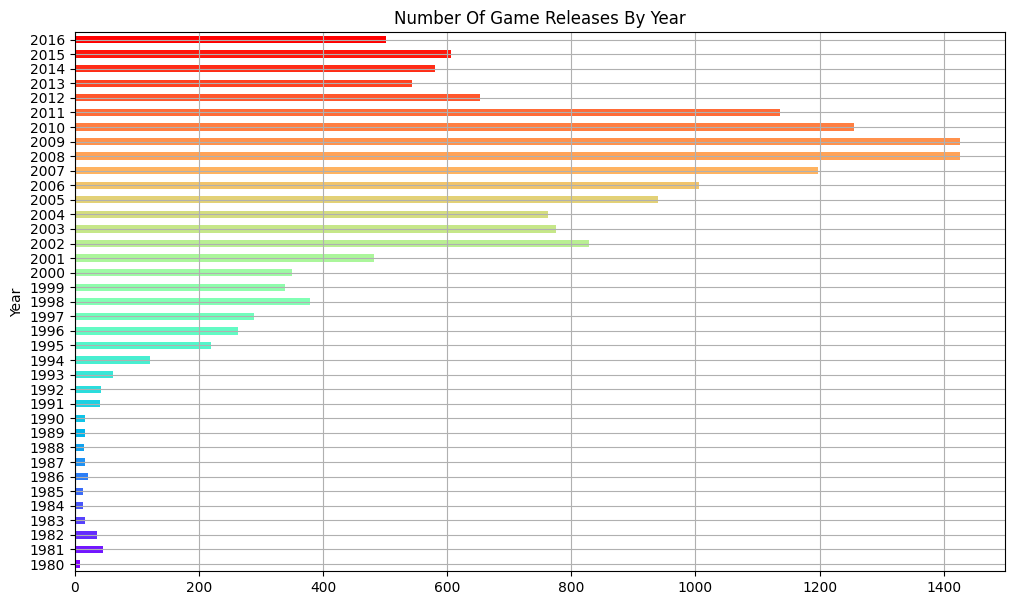

In [ ]:
# Visualize the distribution of games across years
rainbow_colors = plt.cm.rainbow(np.linspace(0, 1, len(df_games_per_year)))
df_games_per_year.plot(x='year_of_release',
                       y='number_of_games',
                       kind='barh',
                       figsize=[12,7],
                       legend = False,
                       grid=True,
                       xlabel='Year',
                       title='Number Of Game Releases By Year',
                       color=rainbow_colors)
plt.show()

In [ ]:
# Display summary statistics for each year
df_games_per_year

,year_of_release,number_of_games
0,1980,9
1,1981,46
2,1982,36
3,1983,17
4,1984,14
5,1985,14
6,1986,21
7,1987,16
8,1988,15
9,1989,17


### Questions to Consider:
- Which years show significant numbers of game releases?
- Are there any notable trends or patterns in the number of releases?
- Is there enough recent data to make predictions for 2017?

-----

- From the data, the years 2002 through 2011 show significant numbers of game releases.
- After 2011, there was a noticeable decline in the number of releases.
- Between 1983 and 1990, the number of game releases does not show a clear upward or downward trend.
- There is also an early spike in releases around 1981–1982, which may reflect the early growth of the video game industry.
- Overall, the trend later becomes downward, and because the gaming market changed over time.
- Using older data from the peak years would not be the best basis for making predictions for 2017.



-----

## 3.2 Platform Sales Analysis Over Time

Now let's analyze how sales vary across platforms and years:

In [ ]:
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN,31.38


In [ ]:
# Calculate total sales by platform and year
df_sales_by_platform_year = df.groupby(["platform","year_of_release"]).agg( total_sales = ("global_sales","sum"))
df_sales_by_platform_year

total_sales
platform year_of_release             
2600     1980                   11.38
         1981                   35.68
         1982                   28.88
         1983                    5.84
         1984                    0.27
...                               ...
XB       2008                    0.18
XOne     2013                   18.96
         2014                   54.07
         2015                   60.14
         2016                   26.15

[238 rows x 1 columns]

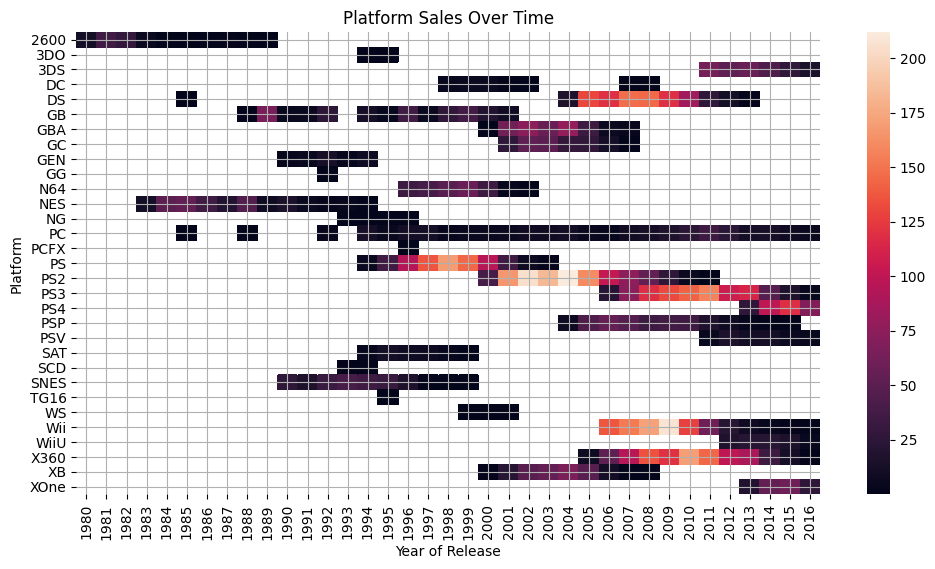

In [ ]:
# Create a heatmap of platform sales over time
heatmap_data = df.pivot_table(index='platform',
                              columns='year_of_release',
                              values='global_sales',
                              aggfunc='sum')
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data)

plt.title('Platform Sales Over Time')
plt.xlabel('Year of Release')
plt.ylabel('Platform')
plt.grid(True)
plt.show()

In [ ]:
# Identify platforms with declining sales 2016,2015,

### Questions to Consider:
- Which platforms show consistent sales over time?
- Can you identify platforms that have disappeared from the market?
- What's the typical lifecycle of a gaming platform?

-----

- From the heatmap, some platforms such as **X360**, **PS3**, **PS2**, **PS**, and **DS** show a pattern of rising global sales, reaching a peak, and then declining over time.
- The **PC** platform has the longest horizontal span on the heatmap, which suggests that it had the longest market presence.
- However, its sales were generally not as high as those of some other platforms, even though it appears to have strong longevity.
- There are also gaps for some platforms, such as **DS** and **PC**, which may suggest that releases were not continuous every year or that some older games were later released again.
- Overall, the trend shows that platform sales tend to decline over time after reaching peak release periods.
- Finally, platforms such as **3DO**, **GB**, **WS**, **PS2**, **PS**, **N64**, and others appear to faded away from the market, likely because companies stopped producing games for them.
- The game lifecycle seems to last 4-11 years.



-----

## 3.3 Determining Relevant Time Period

Based on your analysis above, determine the appropriate time period for predicting 2017 sales:

In [ ]:
# Your code here to filter the dataset to relevant years

## relevant years df
relevant_years = [2013,2014,2015,2016]
df_relevant = df[df['year_of_release'].isin(relevant_years)]
df_relevant.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,NaN,14.60
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62


### Document Your Decision:
- What years did you select and why?
- How does this period reflect current market conditions?
- What factors influenced your decision?

-----

- Based on my analysis, I chose the years 2013 through 2016 for predicting 2017 sales because using the previous ten years would not be as appropriate.
- The gaming market has changed over time, and global sales have shown a strong decline.
- Platform life cycles have also become shorter, and only a few platforms remain active for long periods.
- For that reason, 2013–2016 best reflects the market conditions most relevant for predicting 2017 sales.


----

## 3.4 Platform Performance Analysis

Using your selected time period, let's analyze platform performance:

In [ ]:
df_relevant.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,NaN,14.60
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62


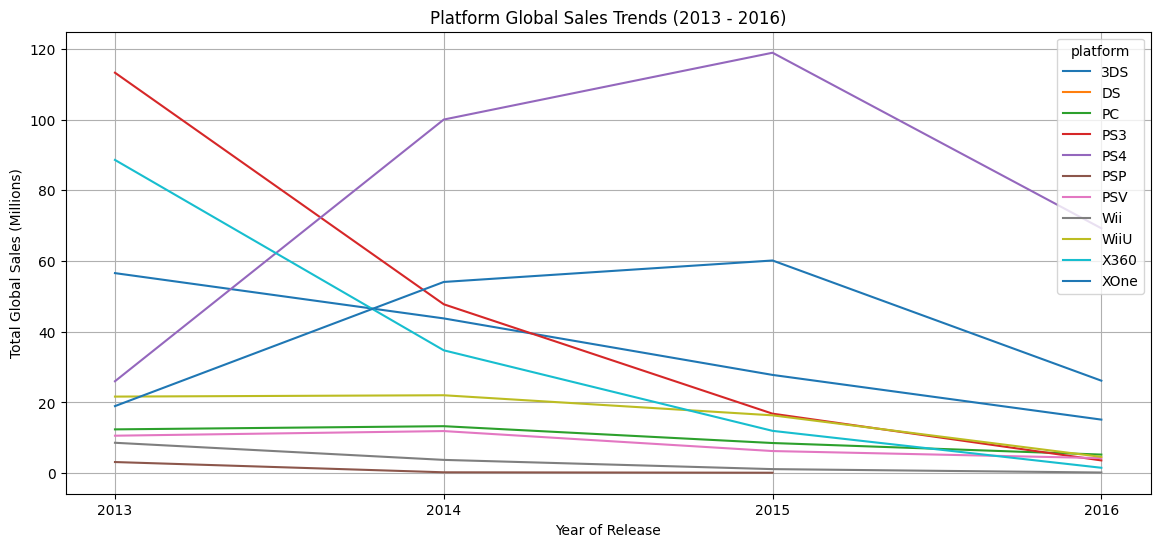

In [ ]:
# Analyze platform sales trends


##  pivot table for sales trends over the relevant years
platform_trends = df_relevant.pivot_table(index='year_of_release',
                                          columns='platform',
                                          values='global_sales',
                                          aggfunc='sum')

platform_trends.plot(figsize=(14, 6),grid=True,
                     title='Platform Global Sales Trends (2013 - 2016)',
                     xlabel='Year of Release',
                     ylabel='Total Global Sales (Millions)')

plt.xticks([2013, 2014, 2015, 2016])
plt.legend(title='platform', loc='upper right')

plt.show()


-----


- From the line graph, overall sales appear to be declining across most platforms.

- The PS4 showed the longest period of growth, rising from 2013 to 2015 before beginning to decline.

- The PSP showed no sales after 2015 in this dataset..




-----

In [ ]:
# Sort platforms by total sales
df_sort_platform_by_sales = df_relevant.groupby("platform").agg(total_sales = ('global_sales','sum')).reset_index().sort_values(by='total_sales',ascending=False)
df_sort_platform_by_sales

,platform,total_sales
4,PS4,314.14
3,PS3,181.43
10,XOne,159.32
0,3DS,143.25
9,X360,136.80
8,WiiU,64.63
2,PC,39.43
6,PSV,32.99
7,Wii,13.66
5,PSP,3.50


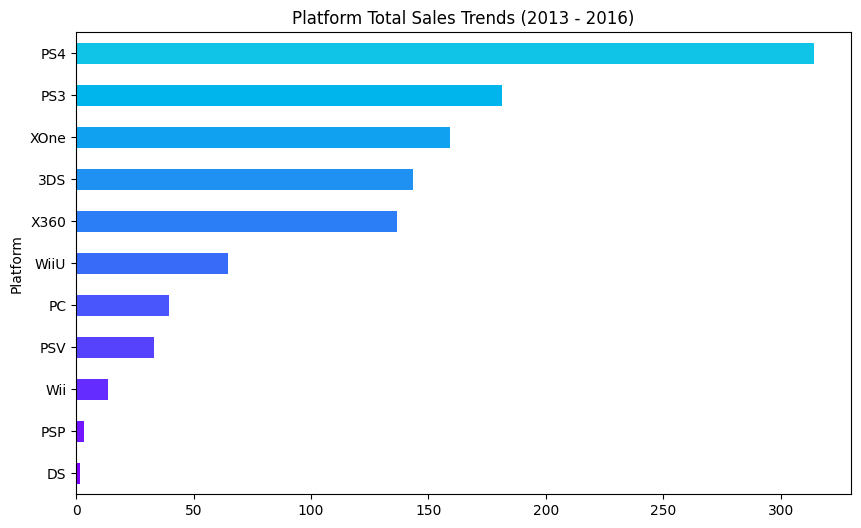

In [ ]:
#Visualize top platforms
# Calculate year-over-year growth for each platform
# Your code here to calculate and visualize platform growth rates

df_sort_platform_by_sales.sort_values(by='total_sales').plot(x='platform',
                                                             y='total_sales',
                                                             kind='barh',
                                                             legend=False,
                                                             title='Platform Total Sales Trends (2013 - 2016)',
                                                             figsize=[10,6],
                                                             color=rainbow_colors,
                                                             xlabel="Platform")

plt.show()

In [ ]:
## regular table
platform_trends

platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
year_of_release,,,,,,,,,,,
2013,56.57,1.54,12.38,113.25,25.99,3.14,10.59,8.59,21.65,88.58,18.96
2014,43.76,NaN,13.28,47.76,100.00,0.24,11.90,3.75,22.03,34.74,54.07
2015,27.78,NaN,8.52,16.82,118.90,0.12,6.25,1.14,16.35,11.96,60.14
2016,15.14,NaN,5.25,3.60,69.25,NaN,4.25,0.18,4.60,1.52,26.15


In [ ]:

## year-over-year growth for each platform
platform_trends_pct_growth = (platform_trends.pct_change() * 100).round(2).fillna(0)
platform_trends_pct_growth


platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
year_of_release,,,,,,,,,,,
2013,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2014,-22.64,0.0,7.27,-57.83,284.76,-92.36,12.37,-56.34,1.76,-60.78,185.18
2015,-36.52,0.0,-35.84,-64.78,18.90,-50.00,-47.48,-69.60,-25.78,-65.57,11.23
2016,-45.50,0.0,-38.38,-78.60,-41.76,0.00,-32.00,-84.21,-71.87,-87.29,-56.52


-----


- From the bar chart, the total sales by platform from 2013 to 2016 show that the top 4 platforms were PS4, PS3, XOne, and 3DS.

- The 4 platforms with the lowest total sales during that period were DS, PSP, Wii, and PSV.

- Based on the table of year-over-year growth by platform, from 2013 to 2014 only PC, PS4, PSV, WiiU, and XOne showed positive growth.

- Among them, PS4 had the largest increase at 284.76%, meaning its sales nearly tripled compared to the previous year.

- During that same period, PSP had the largest negative change at -92.36%.

- From 2014 to 2015, almost every platform experienced a decline compared to the previous year, with the exceptions of PS4 and XOne.

- From 2015 to 2016, every platform showed a negative percent change.

- It is also worth noting that DS generated no revenue from 2014 to 2016.


---

## 3.5 Sales Distribution Analysis

Let's examine the distribution of sales across platforms:

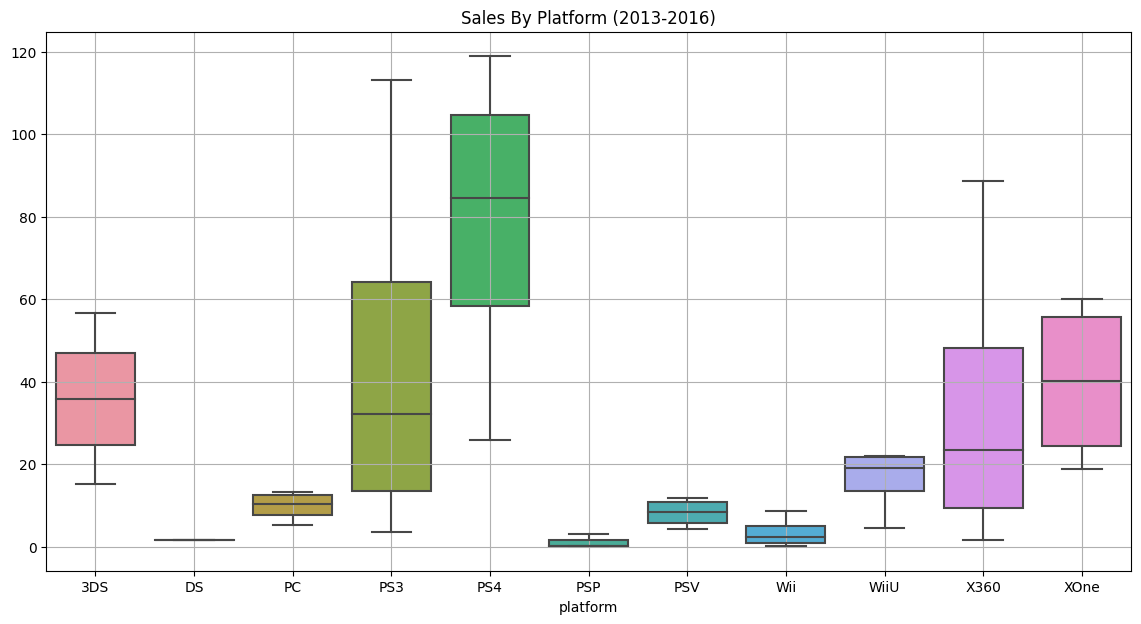

In [ ]:
# Create box plot of sales by platform
## bloxplot
plt.figure(figsize=[14,7])
plt.title('Sales By Platform (2013-2016)')
sns.boxplot(data=platform_trends)
plt.grid(True)
plt.show()

-----

- From the boxplots, PS3, PS4, and X360 appear to show the greatest variance in sales, while DS, PSP, PSV, and Wii show the least.
- The PS4 also appears to have the highest median sales, suggesting that it had the strongest typical sales performance among the platforms shown and PSP being the least.
- Platforms such as PS3, PS4, and X360 also appear to have higher variability in sales, which is consistent with their larger spread in the boxplots.

-----

In [ ]:
# Calculate detailed statistics for each platform

platform_trends.describe()

platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
count,4.000000,1.00,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000
mean,35.812500,1.54,9.857500,45.357500,78.535000,1.166667,8.247500,3.415000,16.157500,34.200000,39.830000
std,18.128338,NaN,3.701102,48.898675,40.567917,1.710010,3.596205,3.765355,8.129507,38.816131,20.313977
min,15.140000,1.54,5.250000,3.600000,25.990000,0.120000,4.250000,0.180000,4.600000,1.520000,18.960000
25%,24.620000,1.54,7.702500,13.515000,58.435000,0.180000,5.750000,0.900000,13.412500,9.350000,24.352500
50%,35.770000,1.54,10.450000,32.290000,84.625000,0.240000,8.420000,2.445000,19.000000,23.350000,40.110000
75%,46.962500,1.54,12.605000,64.132500,104.725000,1.690000,10.917500,4.960000,21.745000,48.200000,55.587500
max,56.570000,1.54,13.280000,113.250000,118.900000,3.140000,11.900000,8.590000,22.030000,88.580000,60.140000


-----

From the summary statistics, PS4, PS3, and XOne had the highest mean sales among all platforms, which suggests that, on average, they generated the most revenue from new releases each year.

The higher standard deviations for PS3, PS4, and X360 suggest that their sales varied more across years than platforms with lower standard deviations.


-----

## 3.6 Review Score Impact Analysis

Select a popular platform and analyze how reviews affect sales:

In [ ]:
# Choose a popular platform based on your previous analysis

## Only ps4 data from relevant
df_relevant_ps4 = df_relevant.query("platform == 'PS4'")
df_relevant_ps4.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62
77,FIFA 16,PS4,2015,Sports,1.12,6.12,0.06,1.28,82.0,4.3,E,8.58
87,Star Wars Battlefront (2015),PS4,2015,Shooter,2.99,3.49,0.22,1.28,NaN,NaN,NaN,7.98
92,Call of Duty: Advanced Warfare,PS4,2014,Shooter,2.81,3.48,0.14,1.23,83.0,5.7,M,7.66


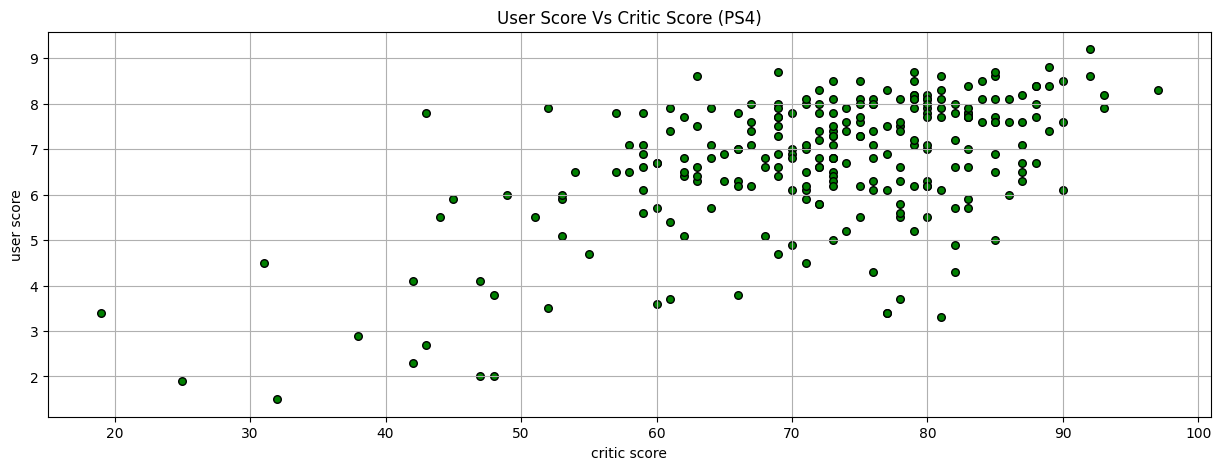

In [ ]:
# Create scatter plots for both critic and user scores

## scatter plot
df_relevant_ps4.plot(x='critic_score',
                     y='user_score',
                     kind='scatter',
                     color='green',
                     edgecolor='black',
                     xlabel='critic score',
                     ylabel='user score',
                     title='User Score Vs Critic Score (PS4)',
                     figsize=[15,5],
                     grid=True,
                     s=30)

plt.show()

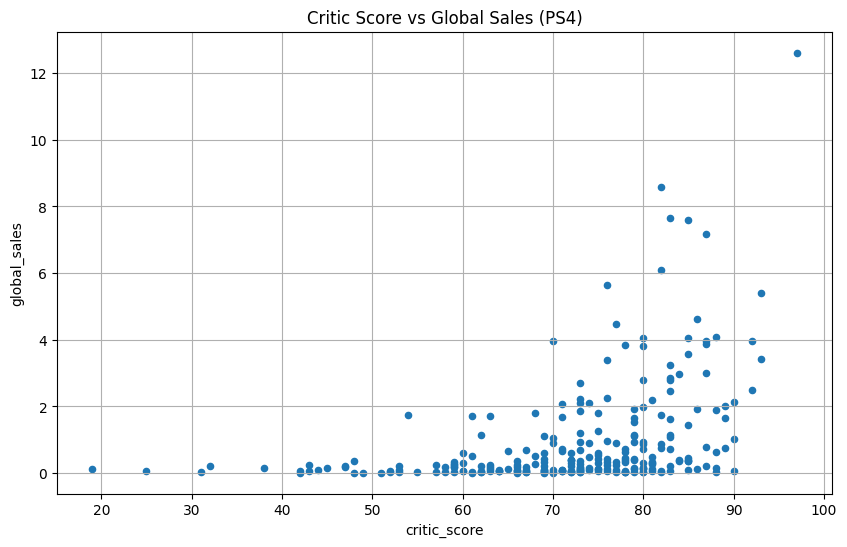

In [ ]:
ps4_data = df_relevant[df_relevant['platform'] == 'PS4']

ps4_data.plot(
    kind='scatter',
    x='critic_score',
    y='global_sales',
    figsize=(10, 6),
    title='Critic Score vs Global Sales (PS4)',
    grid=True
)

plt.show()

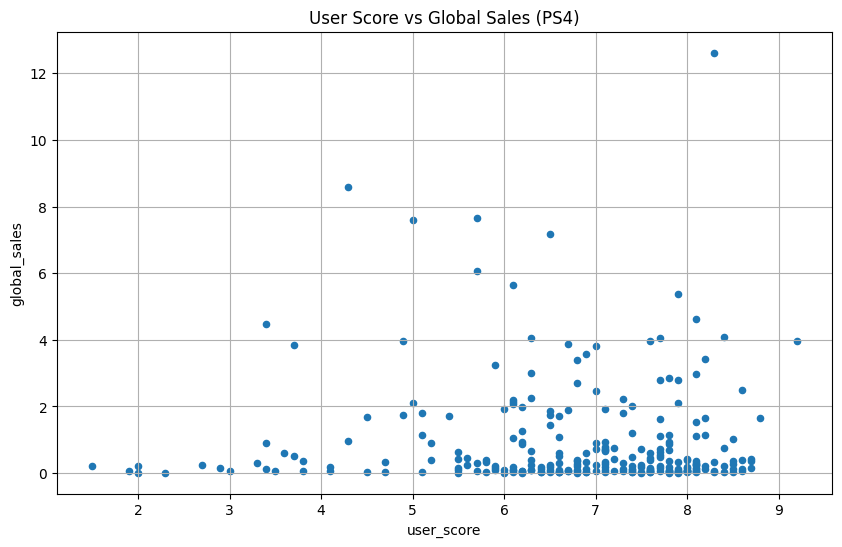

In [ ]:
ps4_data.plot(
    kind='scatter',
    x='user_score',
    y='global_sales',
    figsize=(10, 6),
    title='User Score vs Global Sales (PS4)',
    grid=True
)

plt.show()

In [ ]:
critic_corr = ps4_data['critic_score'].corr(ps4_data['global_sales'])
user_corr = ps4_data['user_score'].corr(ps4_data['global_sales'])

print("Correlation between critic score and global sales:", critic_corr)
print("Correlation between user score and global sales:", user_corr)

Correlation between critic score and global sales: 0.40656790206178095
Correlation between user score and global sales: -0.031957110204556376


In [ ]:
# Critic Scores
df_relevant_ps4['critic_score'].corr(df_relevant_ps4['user_score'])


# User Scores


# Calculate correlations

correlation_userScore_criticScore = df_relevant_ps4['critic_score'].corr(df_relevant_ps4['user_score']).round(2)
print(f"The cor between user score and critic score is {correlation_userScore_criticScore}")

The cor between user score and critic score is 0.56


-----

- From the scatter plots, it appears that both critic scores and user scores have a positive relationship with global sales for PS4 games.

- However, the relationship between critic score and global sales looks stronger than the relationship between user score and global sales.

- The plots show a lot of spread, so neither relationship appears very strong, but higher-scored games generally tend to have higher sales.

- Overall, this suggests that critic scores may be a better predictor of sales than user scores for PS4 games.

-----

## 3.7 Cross-Platform Comparison

Compare sales performance of games across different platforms:

In [ ]:
# Find games released on multiple platforms

## find the number of games on more than one platforms
games_number_of_platforms = df_relevant.groupby('name').agg(number_of_platforms = ('platform','nunique')).reset_index()
games_number_of_platforms

,name,number_of_platforms
0,1/2 Summer +,1
1,12-Sai. Honto no Kimochi,1
2,12-Sai. Koisuru Diary,1
3,2 in 1 Combo Pack: Sonic Heroes / Super Monkey...,1
4,2014 FIFA World Cup Brazil,2
...,...,...
1258,Zoo Tycoon (2013),2
1259,Zumba Fitness: World Party,2
1260,Zyuden Sentai Kyoryuger: Game de Gaburincho!!,1
1261,htoL#NiQ: The Firefly Diary,1


In [ ]:
## name of games of more than 1 platform
games_multi_platforms_df = games_number_of_platforms.query("number_of_platforms >= 2")


## name of those games
name_of_games_multi = games_multi_platforms_df["name"].unique()
df_relevant_multi = df_relevant[df_relevant['name'].isin(name_of_games_multi)]

In [ ]:
## Pivot table for the top 12 best-selling multi-platform games
platform_multi_trends = df_relevant_multi.pivot_table(index='name',
                                          columns='platform',
                                          values='global_sales',
                                          aggfunc='sum',margins=True).fillna(0)

top12 = platform_multi_trends.sort_values(by='All',ascending=False).iloc[1:13,:-1]
top12

platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
name,,,,,,,,,,,
Grand Theft Auto V,0.00,0.0,1.17,21.05,12.62,0.00,0.00,0.00,0.00,16.27,5.47
Call of Duty: Ghosts,0.00,0.0,0.69,9.36,3.83,0.00,0.00,0.00,0.35,10.24,2.92
Call of Duty: Black Ops 3,0.00,0.0,0.26,1.69,14.63,0.00,0.00,0.00,0.00,1.70,7.39
Minecraft,0.00,0.0,0.00,5.27,4.32,0.00,1.96,0.00,0.67,9.18,2.76
Call of Duty: Advanced Warfare,0.00,0.0,0.41,4.36,7.66,0.00,0.00,0.00,0.00,4.28,5.26
FIFA 15,0.46,0.0,0.29,4.28,6.08,0.00,0.60,0.56,0.00,2.92,2.18
FIFA 14,0.23,0.0,0.40,6.46,3.01,0.19,0.41,0.38,0.00,4.22,1.16
FIFA 16,0.00,0.0,0.20,2.70,8.58,0.00,0.00,0.00,0.00,1.57,3.25
Battlefield 4,0.00,0.0,1.36,3.49,3.58,0.00,0.00,0.00,0.00,3.49,2.02


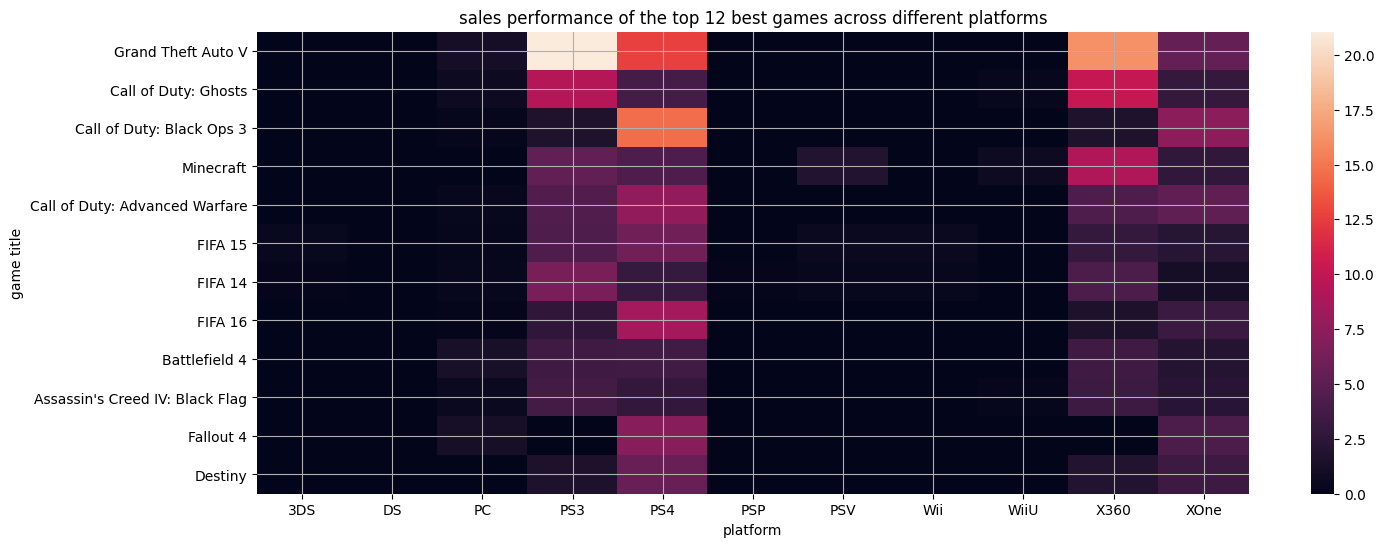

In [ ]:
plt.figure(figsize=(16, 6))
sns.heatmap(top12)

plt.title('sales performance of the top 12 best games across different platforms')
plt.xlabel('platform')
plt.ylabel('game title')
plt.grid(True)
plt.show()

-----

- From the heatmap and table, it appears that the top multi-platform games did not perform equally across all platforms.
- Most of these titles achieved their strongest sales on PS3, PS4, X360, and XOne, while handheld and weaker platforms such as PSP, PSV, Wii, and WiiU generally had much lower sales.
- This suggests that the same game could perform very differently depending on the platform, with larger home consoles providing the strongest market for these top titles.

---

## 3.8 Genre Analysis

Finally, let's examine the distribution of games by genre:

In [ ]:
df_relevant.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,global_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,NaN,14.60
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62


In [ ]:
# Analyze genre performance
genre_sales_df = df_relevant.pivot_table(index='year_of_release',columns='genre',values='global_sales',aggfunc='sum')

## summary stats
genre_sales_df.describe()

genre,Action,Adventure,Fighting,Misc,Platform,Puzzle,Racing,Role-Playing,Shooter,Simulation,Sports,Strategy
count,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
mean,80.467500,5.910000,8.827500,15.705000,10.657500,0.792500,9.972500,36.472500,58.245000,5.440000,37.662500,2.520000
std,39.394548,1.786859,4.905183,10.633816,9.531245,0.614729,5.935163,12.692463,13.537037,2.759626,9.649205,2.429856
min,30.110000,3.820000,4.470000,2.600000,3.230000,0.010000,2.790000,18.180000,38.220000,1.890000,23.490000,0.980000
25%,61.542500,5.132500,6.435000,9.327500,5.345000,0.535000,6.750000,32.775000,56.085000,4.657500,36.502500,1.092500
50%,84.625000,5.830000,7.495000,17.475000,7.430000,0.835000,10.220000,41.045000,63.625000,5.620000,41.005000,1.490000
75%,103.550000,6.607500,9.887500,23.852500,12.742500,1.092500,13.442500,44.742500,65.785000,6.402500,42.165000,2.917500
max,122.510000,8.160000,15.850000,25.270000,24.540000,1.490000,16.660000,45.620000,67.510000,8.630000,45.150000,6.120000


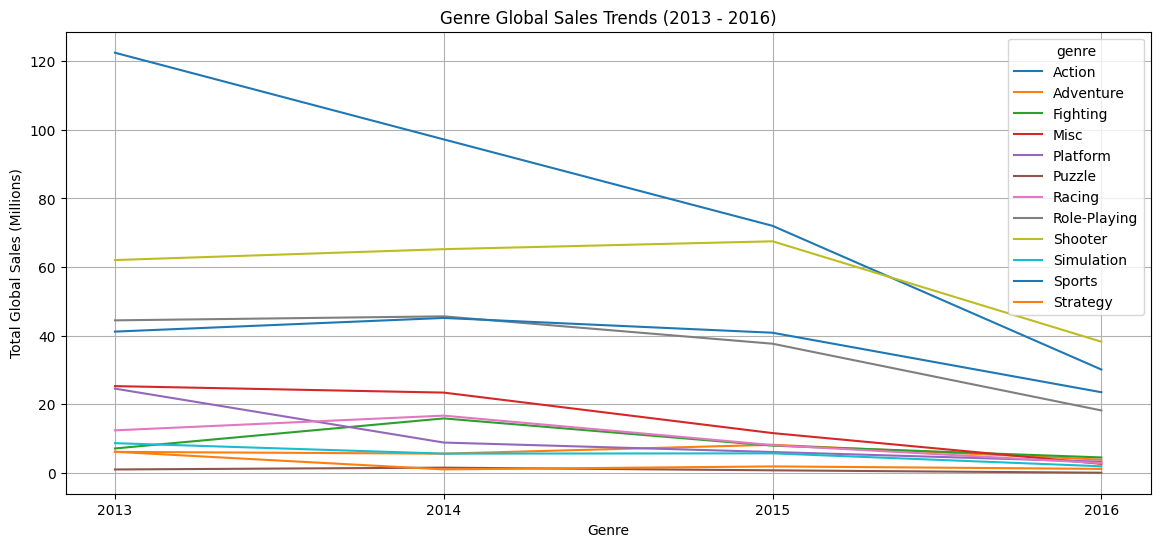

In [ ]:
## line graph of Sales By Genre
genre_sales_df.plot(figsize=(14, 6),grid=True,
                     title='Genre Global Sales Trends (2013 - 2016)',
                     xlabel='Genre',
                     ylabel='Total Global Sales (Millions)')

plt.xticks([2013, 2014, 2015, 2016])
plt.legend(title='genre', loc='upper right')

plt.show()

In [ ]:
# Sort genres by total sales
genre_performance_df = df_relevant.groupby("genre").agg(total_sales = ('global_sales','sum'))
genre_performance_sort_df = genre_performance_df.sort_values(by='total_sales',ascending=False)
genre_performance_sort_df

,total_sales
genre,
Action,321.87
Shooter,232.98
Sports,150.65
Role-Playing,145.89
Misc,62.82
Platform,42.63
Racing,39.89
Fighting,35.31
Adventure,23.64


[]

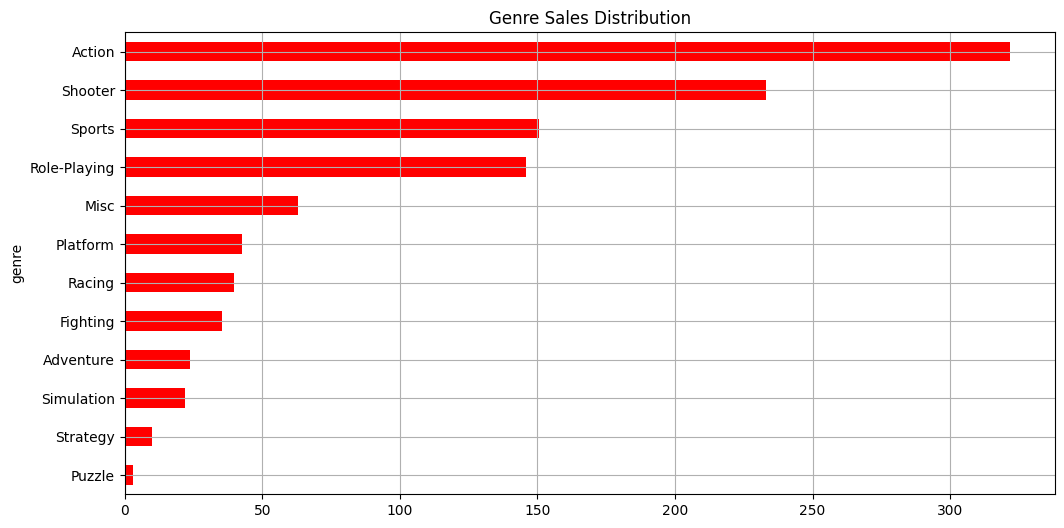

In [ ]:
# Visualize genre distribution
genre_performance_sort_df.sort_values(by='total_sales').plot(kind='barh',
                                                             figsize=[12,6],
                                                             grid=True,
                                                             color='red',
                                                             title='Genre Sales Distribution',
                                                             legend=False)
plt.plot()

[]

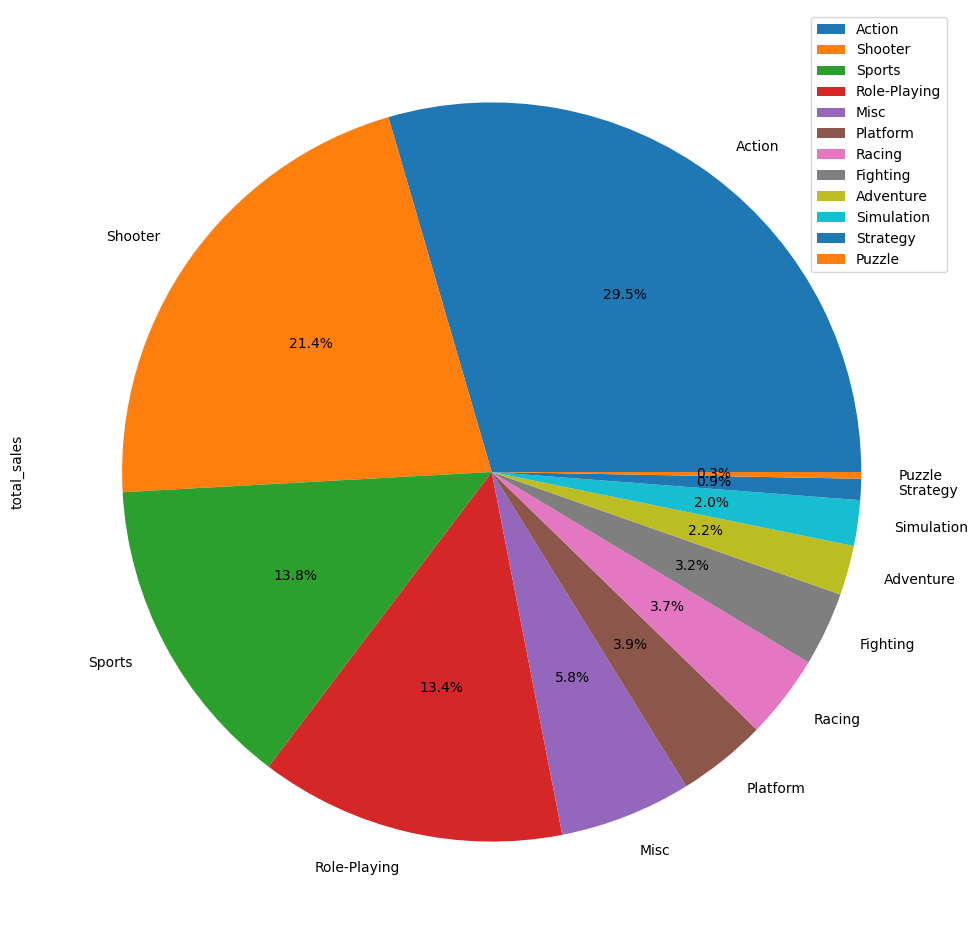

In [ ]:
# Calculate market share for each genre
grand_total = genre_performance_sort_df['total_sales'].sum()
genre_performance_sort_df['percent sales'] = genre_performance_sort_df['total_sales'].apply(lambda x: f"{100*x/grand_total:.2f}%")
genre_performance_sort_df.plot(kind='pie',y='total_sales',autopct='%1.1f%%',figsize=[12,12])
plt.legend(loc='upper right')
plt.plot()

In [ ]:
genre_performance_sort_df

,total_sales,percent sales
genre,,
Action,321.87,29.51%
Shooter,232.98,21.36%
Sports,150.65,13.81%
Role-Playing,145.89,13.38%
Misc,62.82,5.76%
Platform,42.63,3.91%
Racing,39.89,3.66%
Fighting,35.31,3.24%
Adventure,23.64,2.17%


### Key Questions for Genre Analysis:
- Which genres consistently perform well?
- Are there any genres showing recent growth or decline?
- How does the average performance vary across genres?

-----

- From the genre analysis, it appears that Action and Shooter consistently performed the best overall from 2013 to 2016.
- Sports and Role-Playing also performed well compared to the other genres, but they were still below Action and Shooter in total global sales.
- Based on the total sales table, Action had the highest sales at 321.87 million, followed by Shooter at 232.98 million.

-----

-----

- From the line graph, it appears that most genres showed a decline by 2016.
- Action had the strongest sales at the beginning of the period, but it dropped a lot by 2016.
- Shooter stayed relatively strong through 2015, then also declined in 2016.
- Role-Playing and Sports also trended downward near the end.
- There are no genres that show strong recent growth across the full period, since most of them either stayed low or decreased over time.

-----

-----

- From the summary statistics, the average performance varies a lot across genres.
- Action had the highest average yearly sales, with a mean of about 80.47 million, followed by Shooter at about 58.25 million.
- Sports and Role-Playing had moderate average performance, while genres such as Strategy, Simulation, Adventure, and especially Puzzle had much lower average sales.
- This shows that a small number of genres dominated the market, while the weaker genres made up only a small share of total sales.

-----

# Step 4: Regional Market Analysis and User Profiles

In this section, we will analyze the gaming market characteristics across three major regions: North America (NA), Europe (EU), and Japan (JP). Our analysis will focus on platform preferences, genre popularity, and the impact of ESRB ratings in each region.

## 4.1 Regional Platform Analysis

Let's begin by examining platform performance across different regions:

In [ ]:
# Function to analyze platform performance by region

## long data frame
df_relevant_long = df_relevant.melt(id_vars=(['name','platform','year_of_release','genre','other_sales','critic_score','user_score','rating','global_sales']),
                                    value_name = 'sales',
                                    var_name = 'country')

df_relevant_long['country'] = df_relevant_long['country'].apply(lambda x: x.split('_')[0])


## function
def best_platforms_by_region(df_long,region,top_number=5):
    print('#######################################################')
    print(f"the top {top_number} platforms in sales for the region {region}".title())
    results = df_long.query("country == @region ").groupby('platform').agg(total_sales = ('sales','sum')).nlargest(top_number,'total_sales').reset_index()
    print(results)
    print('#######################################################')

In [ ]:
# Analyze each region

## the three regions
regions  = ['na','jp','eu']
for r in regions:
    best_platforms_by_region(df_relevant_long,r,7)

#######################################################
The Top 7 Platforms In Sales For The Region Na
  platform  total_sales
0      PS4       108.74
1     XOne        93.12
2     X360        81.66
3      PS3        63.50
4      3DS        38.20
5     WiiU        29.21
6       PC        11.11
#######################################################
#######################################################
The Top 7 Platforms In Sales For The Region Jp
  platform  total_sales
0      3DS        67.81
1      PS3        23.35
2      PSV        18.59
3      PS4        15.96
4     WiiU        10.88
5      PSP         3.29
6     X360         0.51
#######################################################
#######################################################
The Top 7 Platforms In Sales For The Region Eu
  platform  total_sales
0      PS4       141.09
1      PS3        67.81
2     XOne        51.59
3     X360        42.52
4      3DS        30.96
5       PC        25.36
6     WiiU        19.85
###

### Cross-Regional Platform Comparison

Let's create a comparative analysis of platform performance across regions:

In [ ]:
# Create a comparative platform analysis
df_relevant_long.pivot_table(index='platform',columns='country',values='sales',aggfunc='sum',margins=True).sort_values(by='All',ascending=False)

country,eu,jp,na,All
platform,,,,
All,392.23,140.78,437.71,970.72
PS4,141.09,15.96,108.74,265.79
PS3,67.81,23.35,63.50,154.66
XOne,51.59,0.34,93.12,145.05
3DS,30.96,67.81,38.20,136.97
X360,42.52,0.51,81.66,124.69
WiiU,19.85,10.88,29.21,59.94
PC,25.36,0.00,11.11,36.47
PSV,6.10,18.59,5.04,29.73


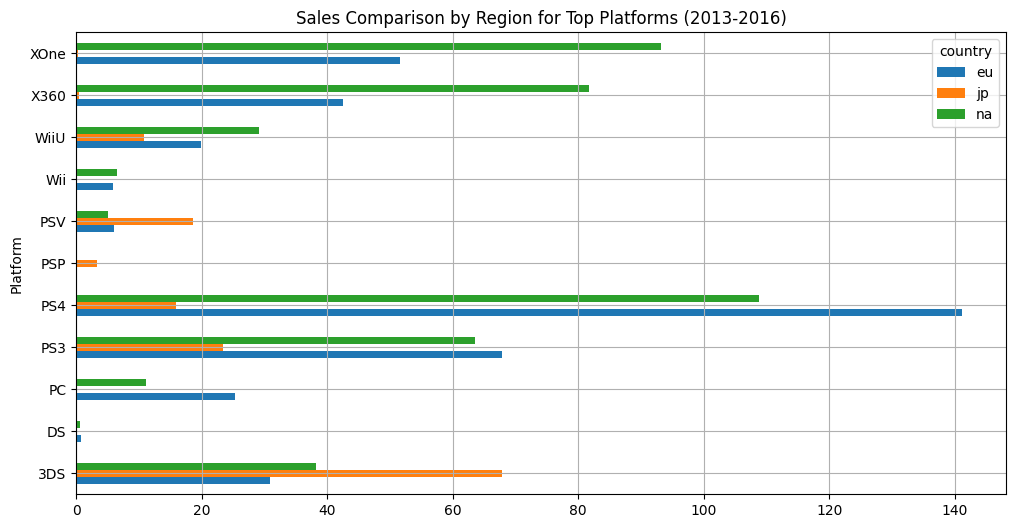

In [ ]:
# Visualize cross-regional comparison for top platforms

df_relevant_long.pivot_table(index='platform',columns='country',values='sales',aggfunc='sum').plot(kind='barh',
                                                                                                   figsize=[12,6],
                                                                                                   title='Sales Comparison by Region for Top Platforms (2013-2016)',
                                                                                                   ylabel='Total Sales (Millions)',
                                                                                                   xlabel='Platform',
                                                                                                   grid=True)

plt.show()



-----

- From the bar chart and summary tables, it appears that North America and Europe had somewhat similar platform preferences, since both regions showed strong sales for PS4, PS3, XOne, and X360.
- However, Japan was much different because 3DS was the top selling platform there by a wide margin, while X360 and XOne had very weak sales.
- This suggests that regional player preferences had a major effect on platform sales, with Xbox performing better in Western markets and Nintendo/PlayStation performing better in Japan.
- This means that game companies should pay attention to regional platform preferences, because the most successful platform in one region may not be the strongest in another.

-----

## 4.2 Regional Genre Analysis

Now let's examine genre preferences across regions:

In [ ]:
df_relevant_long.head()

,name,platform,year_of_release,genre,other_sales,critic_score,user_score,rating,global_sales,country,sales
0,Grand Theft Auto V,PS3,2013,Action,3.96,97.0,8.2,M,21.05,na,7.02
1,Grand Theft Auto V,X360,2013,Action,1.41,97.0,8.1,M,16.27,na,9.66
2,Call of Duty: Black Ops 3,PS4,2015,Shooter,2.38,NaN,NaN,NaN,14.63,na,6.03
3,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,0.78,NaN,NaN,NaN,14.60,na,5.28
4,Grand Theft Auto V,PS4,2014,Action,1.97,97.0,8.3,M,12.62,na,3.96


In [ ]:
# Function to analyze genre performance by region


## function
def best_genres_by_region(df_long,region,top_number=5):
    print('#######################################################')
    print(f"the top {top_number} genre in sales for the region {region}".title())
    results = df_long.query("country == @region ").groupby('genre').agg(total_sales = ('sales','sum')).nlargest(top_number,'total_sales').reset_index()
    print(results)
    print('#######################################################')


### Cross-Regional Genre Comparison

Let's compare genre preferences across regions:

In [ ]:
# Create a comparative genre analysis

for r in regions:
    best_genres_by_region(df_relevant_long,r,10)

#######################################################
The Top 10 Genre In Sales For The Region Na
          genre  total_sales
0        Action       126.05
1       Shooter       109.74
2        Sports        65.27
3  Role-Playing        46.40
4          Misc        27.49
5      Platform        18.14
6      Fighting        15.55
7        Racing        12.96
8     Adventure         7.14
9    Simulation         4.86
#######################################################
#######################################################
The Top 10 Genre In Sales For The Region Jp
          genre  total_sales
0  Role-Playing        51.04
1        Action        40.49
2          Misc         9.20
3      Fighting         7.65
4       Shooter         6.61
5     Adventure         5.82
6        Sports         5.41
7      Platform         4.79
8    Simulation         4.52
9        Racing         2.30
#######################################################
##################################################

-----

- Overall, Action performed well in all three regions, but its dominance was much stronger in North America and Europe.
- Shooter was one of the strongest genres in NA and EU, but it was much weaker in Japan.
- Meanwhile, Role-Playing stood out in Japan and performed much better there than in the other two regions.
- This shows that genre popularity depended a lot on the region, with Western markets favoring Action and Shooter games, while Japan favored Role-Playing games.


-----

## 4.3 ESRB Rating Impact Analysis

Finally, let's examine how ESRB ratings affect sales in each region:

In [ ]:
# Function to analyze ESRB rating impact

## function
def best_rating_by_region(df_long,region,top_number=5):
    print('#######################################################')
    print(f"the top {top_number} ESRB rating in sales for the region {region}".title())
    results = df_long.query("country == @region ").groupby('rating').agg(total_sales = ('sales','sum')).nlargest(top_number,'total_sales').reset_index()
    print(results)
    print('#######################################################')

In [ ]:
# Analyze ESRB impact for each region

for r in regions:
    best_rating_by_region(df_relevant_long,r,4)

#######################################################
The Top 4 Esrb Rating In Sales For The Region Na
  rating  total_sales
0      M       165.21
1      E        79.05
2   E10+        54.24
3      T        49.79
#######################################################
#######################################################
The Top 4 Esrb Rating In Sales For The Region Jp
  rating  total_sales
0      T        20.59
1      E        15.14
2      M        14.11
3   E10+         5.89
#######################################################
#######################################################
The Top 4 Esrb Rating In Sales For The Region Eu
  rating  total_sales
0      M       145.32
1      E        83.36
2   E10+        42.69
3      T        41.95
#######################################################


-----

- In North America, M-rated games led by a large margin with 165.21 in sales, compared with 79.05 for E-rated games.
- In Europe, the pattern was similar, with M-rated games at 145.32, followed by E-rated games at 83.36.
- However, in Japan, T-rated games had the highest sales at 20.59, while M-rated games had 14.11, showing a different consumer preference.
- This suggests that game companies should consider regional preferences when targeting games by rating.
- M-rated titles may have the strongest sales potential in North America and Europe, while T-rated and E-rated titles may be more competitive in Japan.

-----

# Step 5 : Hypothesis Tests

—Average user ratings of the Xbox One and PC platforms are the same.

—Average user ratings for the Action and Sports genres are different.

Set the *alpha* threshold value yourself.

Explain:

—How you formulated the null and alternative hypotheses

—What criteria you used to test the hypotheses~~,~~ and why


In [ ]:
## xbox data
xbox_data = df_relevant_long.query("platform == 'XOne' ")['user_score'].dropna()

## pc data
pc_data = df_relevant_long.query("platform == 'PC' ")['user_score'].dropna()

##################################################################################
##################################################################################

## action data
action_data = df_relevant_long.query("genre == 'Action' ")['user_score'].dropna()

## sports data
sports_data = df_relevant_long.query("genre == 'Sports' ")['user_score'].dropna()

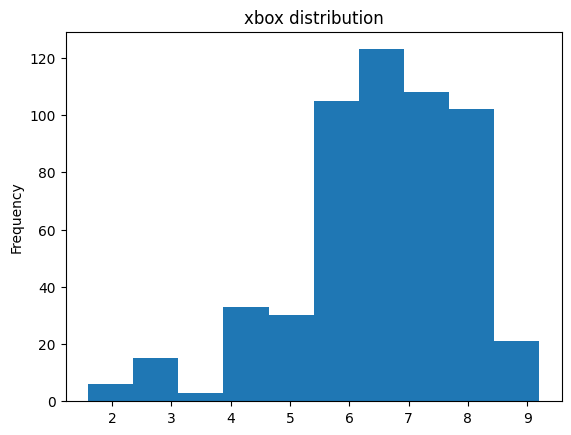

In [ ]:
xbox_data.plot(kind='hist')
plt.title("xbox distribution")
plt.show()

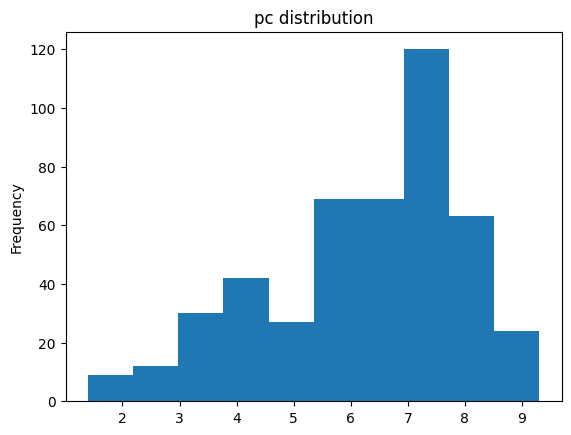

In [ ]:
pc_data.plot(kind='hist')
plt.title("pc distribution")
plt.show()

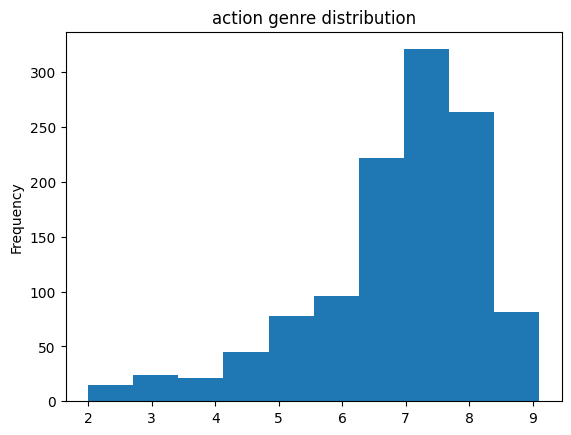

In [ ]:
action_data.plot(kind='hist')
plt.title("action genre distribution")
plt.show()

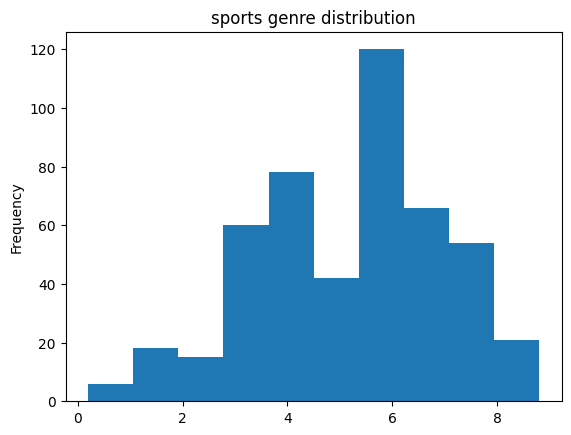

In [ ]:
sports_data.plot(kind='hist')
plt.title("sports genre distribution")
plt.show()

In [ ]:
## shapiro test for normality
var_names = ['xbox platform','pc platform','action genre','sports genre']
datasets = [xbox_data,pc_data,action_data,sports_data]
for name,dataset in zip(var_names,datasets):
    p_value = st.shapiro(dataset).pvalue
    print('#'*130)
    if p_value <= 0.05:
        print(f'for the variable {name}, p-value = {p_value:.7f} <= 0.05, so there is stroong evidence against normality.')
        print('#'*130)
    else:
        print(f'for the variable {name}, p-value = {p_value:.7f} > 0.05, so there is not strong evidence against normality.')
        print('#'*130)


##################################################################################################################################
for the variable xbox platform, p-value = 0.0000000 <= 0.05, so there is stroong evidence against normality.
##################################################################################################################################
##################################################################################################################################
for the variable pc platform, p-value = 0.0000000 <= 0.05, so there is stroong evidence against normality.
##################################################################################################################################
##################################################################################################################################
for the variable action genre, p-value = 0.0000000 <= 0.05, so there is stroong evidence against normality.
#####################

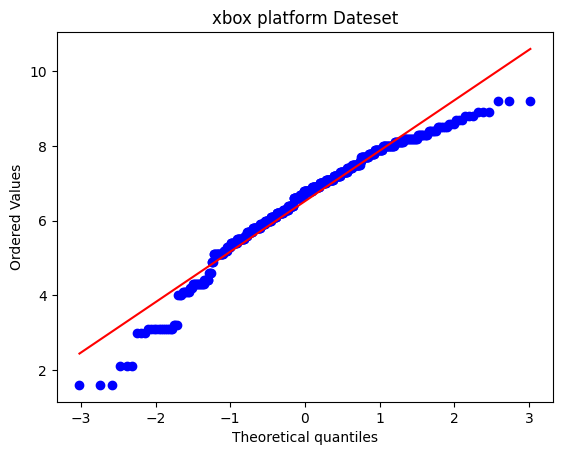

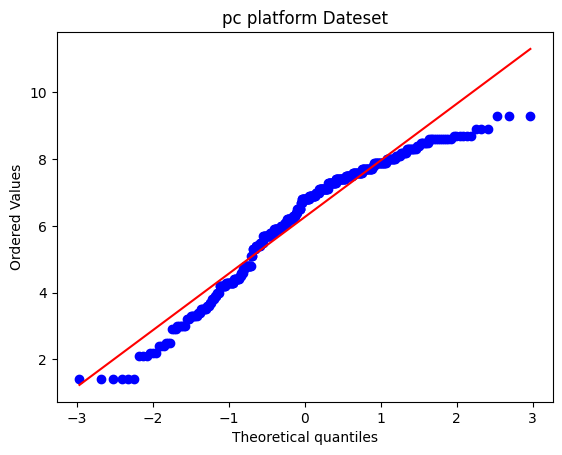

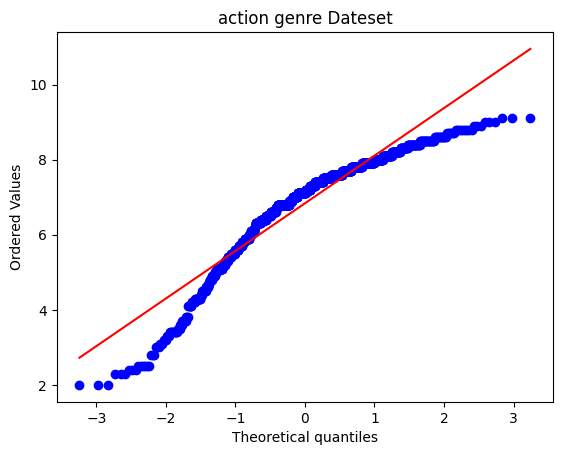

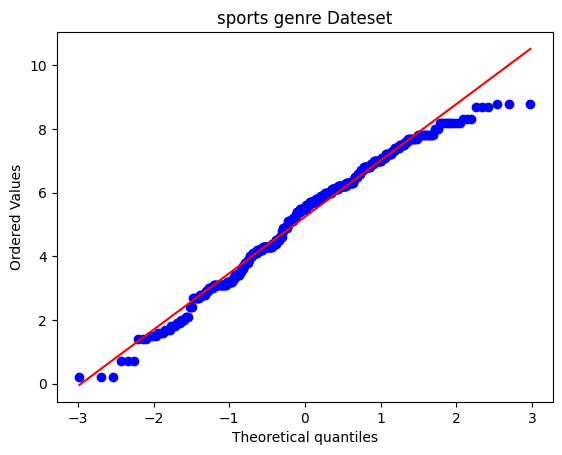

In [ ]:
## qq-plot
for name,dataset in zip(var_names,datasets):
    st.probplot(dataset, plot=plt)
    plt.title(f"{name} Dateset")
    plt.show()

-----


- To assess the normality assumption for the t-tests, I used histograms, Shapiro–Wilk tests, and Q-Q plots for the Xbox One, PC, Action, and Sports user-rating distributions.

- The Shapiro–Wilk results produced p-values below 0.05 for all four groups, indicating evidence against perfect normality.

- The Q-Q plots also show noticeable deviations from the straight line, especially near the lower and upper tails, which suggests some non-normality.

- Even so the distributions remain reasonably well-behaved overall, with no extremely severe outliers and the sample sizes are large.

- Since the two-sample t-test is generally robust to moderate non-normality in large samples, it is still an appropriate method here.

- Thereroe, the normality assumption is not exact, but it is acceptable enough for these hypothesis test.


-----

In [ ]:
print('##################################################################################')

print("H0: mu_xbox_user_ratings = mu_pc_user_ratings")
print("H1: mu_xbox_user_ratings != mu_pc_user_ratings")
print('##################################################################################')

## mean
xbar_xbox = np.mean(xbox_data)
xbar_pc = np.mean(pc_data)

## difference
diff = (xbar_xbox-xbar_pc)

## sd
sd_xbox = np.std(xbox_data,ddof=1)
sd_pc = np.std(pc_data,ddof=1)

## var
var_xbox = np.var(xbox_data,ddof=1)
var_pc = np.var(pc_data,ddof=1)

## n
n_xbox = len(xbox_data)
n_pc = len(pc_data)

## alpha
alpha = 0.05

## F-statistic
fstat,big_df,small_df = [var_xbox/var_pc,n_xbox-1,n_pc-1] if var_xbox>var_pc else [var_pc/var_xbox,n_pc-1,n_xbox-1]

## F critical value
f_crit = st.f.ppf(1-alpha,big_df,small_df)

if fstat <= f_crit:
    print('pool equal variance')
else:
    print('unpool unequal variance')
print('##################################################################################')
top = ((var_xbox/n_xbox) + (var_pc/n_pc))**2
bottom = (1/(n_xbox-1)) * (var_xbox/n_xbox)**2 + (1/(n_pc-1)) * (var_pc/n_pc)**2
df = top/bottom

##################################################################################
##################################################################################

## standard error
se = np.sqrt((var_xbox/n_xbox) + (var_pc/n_pc))

## t critical value
t_crit = st.t.ppf(1-alpha/2,df)

## t test stat
ttest_stat = diff/se

## p value
pvalue = 2*(st.t.sf(abs(ttest_stat),df))

if pvalue <= alpha:
    print('reject H0')
else:
    print('fail to reject H0')
print(f"test-stat: {ttest_stat:.5f}")
print(f"p-value: {pvalue:.5f}")
print('##################################################################################')
lower_bound = round(diff - t_crit*se,2)
upper_bound = round(diff + t_crit*se,2)
print(f'Confindence interval ({lower_bound},{upper_bound})')
print('##################################################################################')

##################################################################################
H0: mu_xbox_user_ratings = mu_pc_user_ratings
H1: mu_xbox_user_ratings != mu_pc_user_ratings
##################################################################################
unpool unequal variance
##################################################################################
reject H0
test-stat: 2.51997
p-value: 0.01191
##################################################################################
Confindence interval (0.06,0.45)
##################################################################################


-----

- I set the significance level at alpha = 0.05.

- The null hypothesis was that the average user ratings for Xbox One and PC are equal:


H0: mu_XboxOne = mu_PC

- The alternative hypothesis was that the average user ratings for Xbox One and PC are different:


H1: mu_XboxOne != mu_PC

- I used a two-sided two-sample t-test because I was comparing the means of two independent groups and wanted to test for any difference, not just whether one was larger.

- I first checked whether the variances should be treated as equal or unequal. Since the results indicated unequal variances, I used the unpooled version of the two-sample t-test (Welch’s t-test).

- This test assumes the observations are independent and that the sampling distribution of the means is approximately normal, which is reasonable here because of the sample sizes.

- Since the p-value is less than 0.05, I reject the null hypothesis.

- Therefore, there is sufficient evidence to conclude that the average user ratings for Xbox One and PC are significantly different.

- The 95% confidence interval for the difference in population means is (0.06, 0.45).

- Because the entire interval is positive or does not contain zero, this suggests that Xbox One games have slightly higher average user ratings than PC games by about 0.06 to 0.45 points on average.



----

In [ ]:
print('##################################################################################')

print("H0: mu_action_user_ratings = mu_sports_user_ratings")
print("H1: mu_action_user_ratings != mu_sports_user_ratings")
print('##################################################################################')

## mean
xbar_action = np.mean(action_data)
xbar_sports = np.mean(sports_data)

## difference
diff = (xbar_action-xbar_sports)

## sd
sd_action = np.std(action_data,ddof=1)
sd_sports = np.std(sports_data,ddof=1)

## var
var_action = np.var(action_data,ddof=1)
var_sports = np.var(sports_data,ddof=1)

## n
n_action = len(action_data)
n_sports = len(sports_data)

## alpha
alpha = 0.05

## F-statistic
fstat,big_df,small_df = [var_action/var_sports,n_action-1,n_sports-1] if var_action>var_sports else [var_sports/var_action,n_sports-1,n_action-1]

## F critical value
f_crit = st.f.ppf(1-alpha,big_df,small_df)

if fstat <= f_crit:
    print('pool equal variance')
else:
    print('unpool unequal variance')
print('##################################################################################')
top = ((var_action/n_action) + (var_sports/n_sports))**2
bottom = (1/(n_action-1)) * (var_action/n_action)**2 + (1/(n_sports-1)) * (var_sports/n_sports)**2
df = top/bottom

##################################################################################
##################################################################################

## standard error
se = np.sqrt((var_action/n_action) + (var_sports/n_sports))

## t critical value
t_crit = st.t.ppf(1-alpha/2,df)

## t test stat
ttest_stat = diff/se

## p value
pvalue = 2*(st.t.sf(abs(ttest_stat),df))

if pvalue <= alpha:
    print('reject H0')
else:
    print('fail to reject H0')
print(f"test-stat: {ttest_stat:.5f}")
print(f"p-value: {pvalue:.5f}")
print('##################################################################################')
lower_bound = round(diff - t_crit*se,2)
upper_bound = round(diff + t_crit*se,2)
print(f'Confindence interval ({lower_bound},{upper_bound})')
print('##################################################################################')

##################################################################################
H0: mu_action_user_ratings = mu_sports_user_ratings
H1: mu_action_user_ratings != mu_sports_user_ratings
##################################################################################
unpool unequal variance
##################################################################################
reject H0
test-stat: 17.75785
p-value: 0.00000
##################################################################################
Confindence interval (1.42,1.78)
##################################################################################


-----



- I set the significance level at alpha = 0.05.

- The null hypothesis was that the average user ratings for Action and Sports games are equal:

  
-H0: mu_Action = mu_Sports

- The alternative hypothesis was that the average user ratings for Action and Sports games are different:

  
H1: mu_Action != mu_Sports

- I used a two-sided two-sample t-test because I was comparing the means of two independent genres and wanted to test whether their average user ratings differed in either direction.

- I also checked whether the group variances should be treated as equal or unequal. Based on that check, I used the appropriate two-sample t-test, with unequal variances if needed.

- The test relies on the assumptions that the ratings are independent and that the mean ratings are approximately normally distributed, which is reasonable for this comparison.

- Since the p-value is less than 0.05, I reject the null hypothesis.

- Therefore, there is sufficient evidence to conclude that the average user ratings for Action and Sports games are significantly different.

- The 95% confidence interval for the difference in population means is (1.42, 1.78).

- Because the whole interval does not contain zero, this indicates that on average, Action games have higher  user ratings than Sports games, by about 1.42 to 1.78 points.



-----

# Step 6. Write a general conclusion


-----
Based on this analysis, several important patterns help explain video game success. After cleaning the data and handling missing values, I found that the most relevant period for predicting 2017 sales is 2013 to 2016, since older data reflects a different market and platform environment. During this period, the market showed an overall decline in game sales, and platform life cycles appeared shorter than in earlier years.

-----
Among platforms, PS4, PS3, XOne, and 3DS were the strongest overall in total sales, with PS4 showing the best overall performance and strongest average sales. Many platforms followed a common pattern of growth, peak sales, and decline over time, while some older platforms disappeared completely from the market. This suggests that platform timing and market relevance are important factors in a game’s success.

-----
Genre analysis showed that Action and Shooter were the strongest-performing genres overall, while weaker genres such as Puzzle, Strategy, and Simulation had much lower sales. However, genre performance also depended on the region. North America and Europe had similar preferences, especially for Action and Shooter games, while Japan showed different preferences, with Role-Playing performing much better there.

-----
Regional analysis also showed clear platform differences. PS4, PS3, XOne, and X360 performed strongly in North America and Europe, while 3DS was much more dominant in Japan. ESRB ratings also appeared to affect sales differently across regions, with M-rated games leading in North America and Europe, while T-rated games performed better in Japan. This means advertising and sales strategy should be adjusted by region rather than treated as one global market.

-----
The review analysis suggested that review scores had some relationship with sales, but the relationship was stronger for critic scores than for user scores. For PS4 games, higher critic scores appeared to be associated with higher global sales, while the relationship between user scores and sales was weaker. In addition, top multi-platform games did not perform equally across all consoles. Stronger home consoles such as PS3, PS4, X360, and XOne generally had better sales for major titles than weaker or handheld platforms.

-----
Finally, the hypothesis tests showed that the average user ratings for Xbox One and PC were significantly different, and the average user ratings for Action and Sports games were also significantly different. Although the normality checks showed that the data were not perfectly normal, the sample sizes were large enough for the t-tests to still be appropriate and robust for these comparisons. Overall, the results suggest that game success depends on a combination of platform strength, genre, region, and market timing. For planning a 2017 advertising campaign, the most promising focus would be on strong current platforms such as PS4 and XOne, high-performing genres such as Action and Shooter, and region-specific strategies based on local platform and genre preferences.

-----